In [1]:
# %% [markdown]
# # lab3: 두 큐빗의 얽힘 (entanglement)
# ### 양자 머신러닝 실습 (PennyLane · Colab)
#
# **핵심 예제**: 벨 상태 Φ⁺ = (|00⟩ + |11⟩)/√2  (H + CNOT)
#
# **학습 목표**
# 1. H + CNOT 로 얽힌 벨 상태를 만든다.
# 2. 벨 상태는 00·11 만 나온다 = 두 큐빗의 측정이 완벽히 상관된다.
# 3. CNOT 이 없는 곱 상태(얽힘 없음)와 비교한다.
# 4. 한 큐빗만 보면 50:50 무작위 — 정보는 '상관'에만 있다.
# 5. (3-4) 기저를 바꿔 측정하면 얽힘과 '고전적 상관'이 갈린다.
#
# lab1·lab2의 shots·측정 패턴을 그대로 사용한다.
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행
!pip install -q pennylane

In [2]:
import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 1234
dev = qml.device("default.qubit", wires=2, seed=SEED)   # 큐빗 2개
KEYS = ["00", "01", "10", "11"]



In [3]:
def frac(counts, shots):
    """counts 딕셔너리를 00/01/10/11 확률로 변환."""
    return {b: counts.get(b, 0) / shots for b in KEYS}


def plot_one(dist, title, ylabel="probability"):
    """단일 분포 막대그래프 (00·11 파랑, 01·10 회색)."""
    fig, ax = plt.subplots(figsize=(5, 4))
    colors = ["#2a78d6" if b in ("00", "11") else "#c3c2b7" for b in KEYS]
    ax.bar(KEYS, [dist[b] for b in KEYS], color=colors)
    ax.set_ylim(0, 1)
    ax.set_xlabel("measured outcome (qubit0 qubit1)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_two(dist_a, dist_b, label_a, label_b, title):
    """두 분포 나란히 비교."""
    x = std_np.arange(4)
    w = 0.38
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(x - w / 2, [dist_a[b] for b in KEYS], w, label=label_a, color="#2a78d6")
    ax.bar(x + w / 2, [dist_b[b] for b in KEYS], w, label=label_b, color="#eb6834")
    ax.set_xticks(x)
    ax.set_xticklabels(KEYS)
    ax.set_ylim(0, 0.62)
    ax.set_xlabel("measured outcome (qubit0 qubit1)")
    ax.set_ylabel("probability")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()



lab3-1: 벨 상태 — H + CNOT

[벨 회로]
0: ──H─╭●─┤  Counts
1: ────╰X─┤  Counts


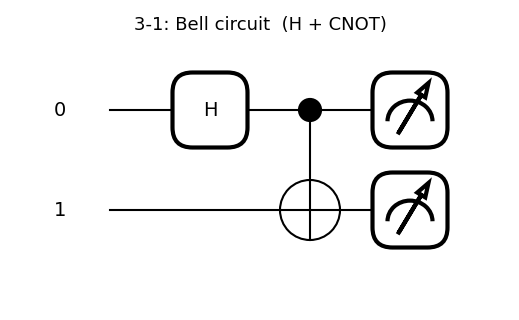


측정 확률: {'00': np.float64(0.492), '01': 0.0, '10': 0.0, '11': np.float64(0.508)}
=> 00 과 11 만 나온다. 01·10 은 0 = 두 큐빗이 항상 '같은 값'으로 상관.


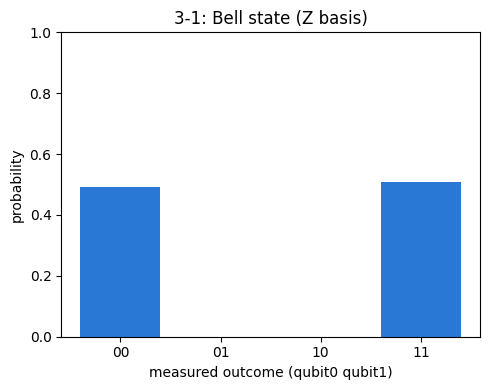

In [4]:
# %%
# ===========================================================
#  3-1: 벨 상태 만들기 & Z 기저 측정
# ===========================================================
print("=" * 60)
print("lab3-1: 벨 상태 — H + CNOT")
print("=" * 60)


@qml.qnode(dev)
def bell_z():
    qml.Hadamard(0)        # 큐빗0 을 중첩으로
    qml.CNOT([0, 1])       # 큐빗0 이 1이면 큐빗1 도 뒤집음 -> 얽힘
    return qml.counts()


# 회로도 (텍스트 + 그림)
print("\n[벨 회로]")
print(qml.draw(bell_z)())
fig, ax = qml.draw_mpl(bell_z, style="black_white")()
fig.suptitle("3-1: Bell circuit  (H + CNOT)", fontsize=13)
plt.tight_layout()
plt.show()

bell = frac(qml.set_shots(bell_z, shots=4000)(), 4000)
print("\n측정 확률:", {k: round(v, 3) for k, v in bell.items()})
print("=> 00 과 11 만 나온다. 01·10 은 0 = 두 큐빗이 항상 '같은 값'으로 상관.")
plot_one(bell, "3-1: Bell state (Z basis)")



lab3-2: CNOT 을 빼면? (곱 상태, 얽힘 없음)

[곱 상태 회로]
0: ──H─┤  Counts
1: ──H─┤  Counts


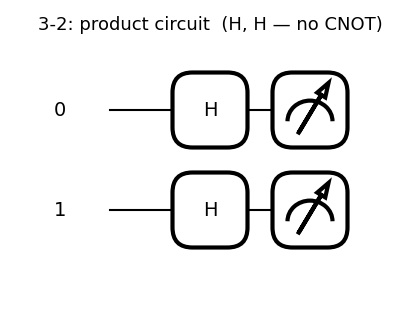

In [5]:
# %%
# ===========================================================
#  3-2: 얽힘 없는 곱 상태와 비교
# ===========================================================
print("\n" + "=" * 60)
print("lab3-2: CNOT 을 빼면? (곱 상태, 얽힘 없음)")
print("=" * 60)


@qml.qnode(dev)
def product_z():
    qml.Hadamard(0)        # 두 큐빗을 각각 독립적으로 중첩
    qml.Hadamard(1)        # (CNOT 없음 -> 얽힘 없음)
    return qml.counts()


print("\n[곱 상태 회로]")
print(qml.draw(product_z)())
fig, ax = qml.draw_mpl(product_z, style="black_white")()
fig.suptitle("3-2: product circuit  (H, H — no CNOT)", fontsize=13)
plt.tight_layout()
plt.show()



측정 확률: {'00': np.float64(0.245), '01': np.float64(0.248), '10': np.float64(0.255), '11': np.float64(0.252)}
=> 네 결과가 골고루(각 25%). 두 큐빗이 서로 무관 = 상관 없음.


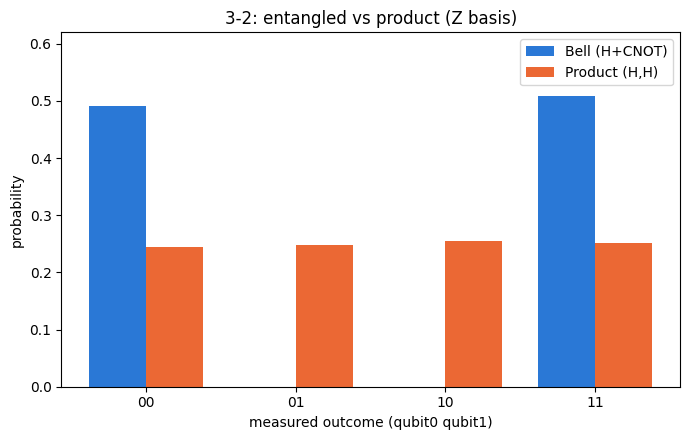

In [6]:

product = frac(qml.set_shots(product_z, shots=4000)(), 4000)
print("\n측정 확률:", {k: round(v, 3) for k, v in product.items()})
print("=> 네 결과가 골고루(각 25%). 두 큐빗이 서로 무관 = 상관 없음.")
plot_two(bell, product, "Bell (H+CNOT)", "Product (H,H)",
         "3-2: entangled vs product (Z basis)")




lab3-3: 벨 상태에서 큐빗 하나만 측정

큐빗0 단독 측정 확률:  P(0)=0.500,  P(1)=0.500
=> 한 큐빗만 보면 완전한 50:50 무작위. 특별할 게 없다.
   얽힘의 정보는 개별 큐빗이 아니라 '둘 사이의 상관'에만 들어 있다.


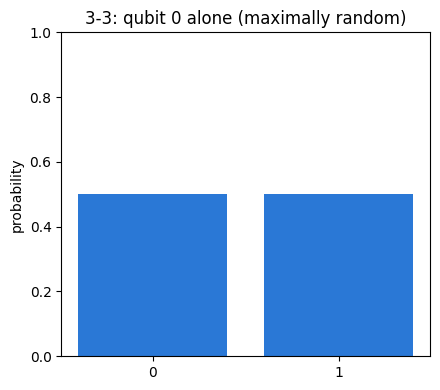

In [8]:

# %%
# ===========================================================
#  3-3: 한 큐빗만 보면? — 정보는 '상관'에만 있다
# ===========================================================
print("\n" + "=" * 60)
print("lab3-3: 벨 상태에서 큐빗 하나만 측정")
print("=" * 60)


@qml.qnode(dev)
def bell_qubit0():
    qml.Hadamard(0)
    qml.CNOT([0, 1])
    return qml.probs(wires=0)     # 큐빗0 만 본다


p0 = bell_qubit0()
print(f"\n큐빗0 단독 측정 확률:  P(0)={float(p0[0]):.3f},  P(1)={float(p0[1]):.3f}")
print("=> 한 큐빗만 보면 완전한 50:50 무작위. 특별할 게 없다.")
print("   얽힘의 정보는 개별 큐빗이 아니라 '둘 사이의 상관'에만 들어 있다.")

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["0", "1"], [float(p0[0]), float(p0[1])], color="#2a78d6")
ax.set_ylim(0, 1)
ax.set_ylabel("probability")
ax.set_title("3-3: qubit 0 alone (maximally random)")
plt.tight_layout()
plt.show()


In [9]:
# %%
# ===========================================================
#  3-4: 기저를 바꿔 측정 — 얽힘 vs 고전적 상관
# ===========================================================
print("\n" + "=" * 60)
print("lab3-4: '상관'과 '얽힘'은 다르다 (기저 비교)")
print("=" * 60)

# 고전적 상관: 광원이 절반은 |00>, 절반은 |11> 을 보낸다 (미리 정해진 무작위).
#   -> 혼합의 측정 분포 = 0.5*dist(|00>) + 0.5*dist(|11>)


@qml.qnode(dev)
def prepare_and_measure(state11, x_basis):
    if state11:
        qml.PauliX(0); qml.PauliX(1)          # |11> 준비 (아니면 |00>)
    if x_basis:
        qml.Hadamard(0); qml.Hadamard(1)      # X 기저로 회전 후 측정
    return qml.counts()


def classical_mixture(x_basis, shots=4000):
    c00 = frac(qml.set_shots(prepare_and_measure, shots=shots)(False, x_basis), shots)
    c11 = frac(qml.set_shots(prepare_and_measure, shots=shots)(True, x_basis), shots)
    return {b: 0.5 * (c00[b] + c11[b]) for b in KEYS}


@qml.qnode(dev)
def bell_xbasis():
    qml.Hadamard(0); qml.CNOT([0, 1])         # 벨 상태
    qml.Hadamard(0); qml.Hadamard(1)          # X 기저로 회전 후 측정
    return qml.counts()




lab3-4: '상관'과 '얽힘'은 다르다 (기저 비교)



[벨 상태 X 기저 측정 회로]
0: ──H─╭●──H─┤  Counts
1: ────╰X──H─┤  Counts


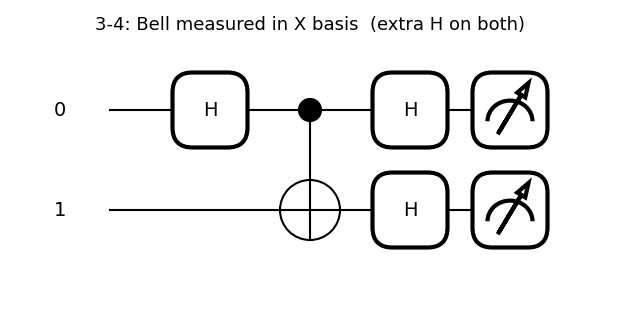

In [11]:

# 벨 상태를 X 기저로 재는 회로도
print("\n[벨 상태 X 기저 측정 회로]")
print(qml.draw(bell_xbasis)())
fig, ax = qml.draw_mpl(bell_xbasis, style="black_white")()
fig.suptitle("3-4: Bell measured in X basis  (extra H on both)", fontsize=13)
plt.tight_layout()
plt.show()



[Z 기저] 벨: {'00': np.float64(0.492), '01': 0.0, '10': 0.0, '11': np.float64(0.508)}
[Z 기저] 고전혼합: {'00': np.float64(0.5), '01': 0.0, '10': 0.0, '11': np.float64(0.5)}
=> Z 기저에서는 둘 다 00/11 만 나온다. 구별 불가!


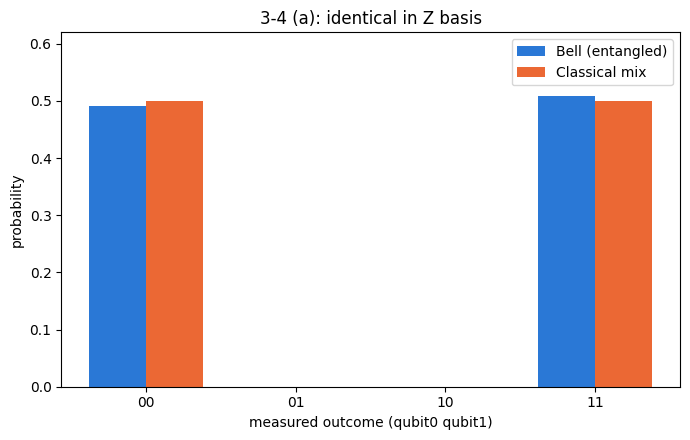

In [12]:

# (가) Z 기저: 벨과 고전 혼합이 '똑같아' 보인다
bell_Z = bell                       # 3-1 결과 재사용
clas_Z = classical_mixture(x_basis=False)
print("\n[Z 기저] 벨:", {k: round(v, 3) for k, v in bell_Z.items()})
print("[Z 기저] 고전혼합:", {k: round(v, 3) for k, v in clas_Z.items()})
print("=> Z 기저에서는 둘 다 00/11 만 나온다. 구별 불가!")
plot_two(bell_Z, clas_Z, "Bell (entangled)", "Classical mix",
         "3-4 (a): identical in Z basis")



[X 기저] 벨: {'00': np.float64(0.514), '01': 0.0, '10': 0.0, '11': np.float64(0.486)}
[X 기저] 고전혼합: {'00': np.float64(0.246), '01': np.float64(0.247), '10': np.float64(0.249), '11': np.float64(0.258)}
=> X 기저에서 벨은 여전히 00/11 (상관 유지),
   고전 혼합은 네 결과로 흩어진다 (상관 소멸).
   두 기저 모두에서 상관이 유지되는 것 = 고전적으로 흉내 낼 수 없는 '진짜 얽힘'.


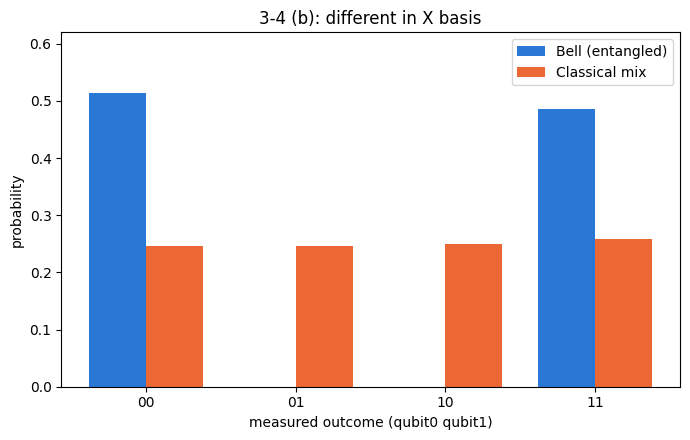

In [13]:

# (나) X 기저: 벨은 상관 유지, 고전 혼합은 무작위로 흩어진다
bell_X = frac(qml.set_shots(bell_xbasis, shots=4000)(), 4000)
clas_X = classical_mixture(x_basis=True)
print("\n[X 기저] 벨:", {k: round(v, 3) for k, v in bell_X.items()})
print("[X 기저] 고전혼합:", {k: round(v, 3) for k, v in clas_X.items()})
print("=> X 기저에서 벨은 여전히 00/11 (상관 유지),")
print("   고전 혼합은 네 결과로 흩어진다 (상관 소멸).")
print("   두 기저 모두에서 상관이 유지되는 것 = 고전적으로 흉내 낼 수 없는 '진짜 얽힘'.")
plot_two(bell_X, clas_X, "Bell (entangled)", "Classical mix",
         "3-4 (b): different in X basis")


In [14]:
# %% [markdown]
# ## 정리
# - 벨 상태(H+CNOT)는 00·11 만 나오는 완벽한 상관을 보인다.
# - CNOT 없는 곱 상태는 상관이 없다 → 상관을 만든 것은 CNOT + 중첩.
# - 한 큐빗만 보면 50:50 무작위 → 정보는 '상관'에만 있다.
# - Z 기저만 보면 얽힘과 고전 상관을 구별할 수 없지만,
#   **X 기저로 바꿔 측정하면** 벨만 상관을 유지한다 = 진짜 얽힘의 지문.
#
# > 주의: "측정이 순간적으로 상대 큐빗을 결정한다"는 맞지만,
# > 이걸로 정보를 빛보다 빠르게 보낼 수는 없다 (no-signaling).
#
# **다음 단계(lab4 후보)**
# - GHZ 상태 (|000⟩+|111⟩)/√2 — 얽힘의 3큐빗 확장
# - CHSH 벨 부등식 위반 (S > 2) — 얽힘이 고전을 이긴다는 정량적 증명